## Cell type neighbor - statistical analysis

In [1]:
import scanpy as sc
import numpy as np
from cozipy.neighbors import knn_graph, radius_graph, delaunay_graph
from cozipy.nep_cozi import run_cozi
import os
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
adata = sc.read_h5ad('/Users/francesca.drummer/Documents/2_Areas/A3-InterScale/data/cosmx_pancreas.h5ad')
adata

AnnData object with n_obs × n_vars = 386727 × 979
    obs: 'fov', 'Area', 'AspectRatio', 'CenterX_global_px', 'CenterY_global_px', 'Width', 'Height', 'Mean.MembraneStain', 'Max.MembraneStain', 'Mean.PanCK', 'Max.PanCK', 'Mean.GCG', 'Max.GCG', 'Mean.CD3', 'Max.CD3', 'Mean.DAPI', 'Max.DAPI', 'cell_ID', 'condition', 'slide', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_NegPrb', 'log1p_total_counts_NegPrb', 'pct_counts_NegPrb', 'n_genes', 'cell_type_coarse', 'CellTypes_max', 'slide_fov', 'slide_condition', 'split', 'split_0', 'split_1', 'split_2', 'globalX', 'globalY', 'sliding_window_square', 'sliding_window_h', 'sliding_window_v'
    obsm: 'X_pca', 'X_umap', 'spatial', 'spatial_fov'
    layers: 'counts'

## COZIpy

### Configuration

COZIpy runs **per sample**, so we loop over the example FOVs of the dataset
(`Ctrl: 1_12`, `T1D: 1_10`, see `figures/config.yml -> slide_examples.Melton_Jimenez`).


In [3]:
import json
from pathlib import Path

REPO_ROOT = Path("/Users/francesca.drummer/Documents/2_Areas/A3-InterScale/code/InterScale_reproducibility")
OUT_DIR = REPO_ROOT / "figures" / "melton_jimenez_25" / "cozipy"
OUT_DIR.mkdir(parents=True, exist_ok=True)

CT_KEY = "cell_type_coarse"   # cell type annotation used as COZIpy labels
SAMPLE_KEY = "slide_fov"      # COZIpy runs per sample -> loop over these
SPATIAL_KEY = "spatial"       # per-FOV coordinates in adata.obsm

SLIDES = {"Ctrl": "1_12", "T1D": "1_10"}   # example FOVs from figures/config.yml

# NEP parameters
NBH_DEF = "radius"
RADIUS = 60                   # same units as adata.obsm[SPATIAL_KEY] (CosMx px)
N_PERMUTATIONS = 300
MIN_CELL_COUNT = 20
RANDOM_STATE = 0

print(adata.obs[SAMPLE_KEY].value_counts().loc[list(SLIDES.values())])

slide_fov
1_12    5208
1_10    4423
Name: count, dtype: int64


### 1. Cell type $\rightarrow$ integer code mapping

`run_cozi` expects integer labels (as in the tutorial, where `labels = df["ct"].values.astype(int)`).
We build the mapping once on the **full** object, so the codes are identical across all samples,
and store it next to the CSVs.


In [4]:
# integer codes 1..n_cell_types, in the order of the categorical
cell_types = list(adata.obs[CT_KEY].cat.categories)
ct_to_code = {ct: i + 1 for i, ct in enumerate(cell_types)}
code_to_ct = {code: ct for ct, code in ct_to_code.items()}

# save the mapping (both directions) as json + csv
with open(OUT_DIR / f"celltype_code_mapping_{CT_KEY}.json", "w") as f:
    json.dump({"ct_to_code": ct_to_code,
               "code_to_ct": {str(k): v for k, v in code_to_ct.items()}}, f, indent=2)

mapping_df = pd.DataFrame({"code": list(code_to_ct.keys()),
                           "cell_type": list(code_to_ct.values())})
mapping_df.to_csv(OUT_DIR / f"celltype_code_mapping_{CT_KEY}.csv", index=False)
mapping_df

,code,cell_type
0,1,Acinar
1,2,Alpha
2,3,Beta
3,4,Ductal
4,5,Endocrine
5,6,Endothelial
6,7,Fibroblasts
7,8,Immune
8,9,Mast


### 2. Write one CSV per slide with `x`, `y`, `ct`

In [5]:
csv_paths = {}

for condition, slide in SLIDES.items():
    mask = (adata.obs[SAMPLE_KEY].astype(str) == slide).values
    coords = np.asarray(adata.obsm[SPATIAL_KEY])[mask].astype(float)

    df = pd.DataFrame({
        "x": coords[:, 0],
        "y": coords[:, 1],
        "ct": adata.obs[CT_KEY][mask].astype(str).map(ct_to_code).astype(int).values,
    })

    path = OUT_DIR / f"{CT_KEY}_{slide}.csv"
    df.to_csv(path, index=False)
    csv_paths[slide] = path
    print(f"{slide} ({condition}): {df.shape[0]} cells, "
          f"{df['ct'].nunique()} cell types -> {path.name}")

df.head()

1_12 (Ctrl): 5208 cells, 9 cell types -> cell_type_coarse_1_12.csv
1_10 (T1D): 4423 cells, 9 cell types -> cell_type_coarse_1_10.csv


,x,y,ct
0,466.0,3597.0,4
1,810.0,3627.0,1
2,1021.0,3630.0,7
3,1602.0,3632.0,4
4,1676.0,3613.0,1


### 3. Run COZIpy

One `run_cozi` call per slide. The `radius_graph` degree is printed as a sanity check for the
chosen `RADIUS` (cells without any neighbor cannot contribute to the NEP score).


In [6]:
res_all = {}

for condition, slide in SLIDES.items():
    df = pd.read_csv(csv_paths[slide])

    coords = df[["x", "y"]].values
    labels = df["ct"].values.astype(int)

    # sanity check of the neighborhood size
    adj = radius_graph(coords.astype(float), RADIUS).tocsr()
    deg = np.asarray(adj.sum(axis=1)).ravel()
    print(f"{slide} ({condition}): radius={RADIUS} -> {deg.mean():.2f} neighbors/cell "
          f"(median {np.median(deg):.0f}), {(deg == 0).sum()} cells without neighbor")

    res = run_cozi(coords,
                   labels,
                   nbh_def=NBH_DEF,
                   radius=RADIUS,
                   n_permutations=N_PERMUTATIONS,
                   random_state=RANDOM_STATE,
                   min_cell_count=MIN_CELL_COUNT,
                   return_df=True,
                   normalize_zscore=False)

    # add readable cell type names + sample annotation
    res["index_cell_type_name"] = res["index_cell_type"].map(code_to_ct)
    res["neighbor_cell_type_name"] = res["neighbor_cell_type"].map(code_to_ct)
    res[SAMPLE_KEY] = slide
    res["condition"] = condition

    res.to_csv(OUT_DIR / f"cozi_nep_{slide}_{CT_KEY}_{NBH_DEF}{RADIUS}.csv", index=False)
    res_all[slide] = res

res_all[SLIDES["Ctrl"]].head()

1_12 (Ctrl): radius=60 -> 2.37 neighbors/cell (median 2), 335 cells without neighbor


Cell type(s) 9 were removed because they have fewer than 20 cells.
1_10 (T1D): radius=60 -> 1.89 neighbors/cell (median 2), 476 cells without neighbor


Cell type(s) 2 were removed because they have fewer than 20 cells.


,index_cell_type,neighbor_cell_type,n_index_cells,n_neighbor_cells,n_index_cells_with_neighbor,n_index_neighbor_edges,zscore,cond_ratio,index_cell_type_name,neighbor_cell_type_name,slide_fov,condition
0,1,1,2580,2580,2088,3826,7.903928,0.809302,Acinar,Acinar,1_12,Ctrl
1,1,2,2580,411,15,17,2.964855,0.005814,Acinar,Alpha,1_12,Ctrl
2,1,3,2580,168,0,0,-72.804713,0.000000,Acinar,Beta,1_12,Ctrl
3,1,4,2580,1059,742,919,0.216038,0.287597,Acinar,Ductal,1_12,Ctrl
4,1,5,2580,41,22,25,9.810706,0.008527,Acinar,Endocrine,1_12,Ctrl


### 4. Dot plot

Dot color = NEP z-score, dot size = conditional neighbor ratio (fraction of index cells with at
least one neighbor of that type). Adapted from the
[COZIpy tutorial](https://github.com/SchapiroLabor/COZIpy/blob/main/tutorial/cozipy_tutorial.ipynb),
with the integer codes translated back to cell type names.


In [7]:
def cozi_dotplot(res, ax=None, title=None, code_to_ct=None, vmax=None, size_scale=600):
    """Visualize NEP results as a dot plot.

    Parameters
    ----------
    res : DataFrame
        Output from run_cozi with columns: index_cell_type, neighbor_cell_type, zscore, cond_ratio.
    ax : matplotlib axes, optional
        Axes to plot into. A new figure is created if None.
    title : str, optional
        Axes title.
    code_to_ct : dict, optional
        Mapping of integer label -> cell type name, used for the tick labels.
    vmax : float, optional
        Symmetric color limit for the z-score. Inferred from the data if None.
    """
    types = sorted(res["index_cell_type"].unique())
    n = len(types)

    z_matrix = res.pivot(index="index_cell_type", columns="neighbor_cell_type",
                         values="zscore").loc[types, types].values
    c_matrix = res.pivot(index="index_cell_type", columns="neighbor_cell_type",
                         values="cond_ratio").loc[types, types].values

    xs, ys = np.meshgrid(range(n), range(n))

    if ax is None:
        fig, ax = plt.subplots(figsize=(5.5, 6))
    else:
        fig = ax.figure

    if vmax is None:
        vmax = np.nanmax(np.abs(z_matrix))

    sc_ = ax.scatter(xs, ys,
                     c=z_matrix.flatten(),
                     s=(c_matrix.flatten() * size_scale),
                     cmap="coolwarm", vmin=-vmax, vmax=vmax,
                     edgecolors="none")

    labels = [code_to_ct[t] for t in types] if code_to_ct is not None else types
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(labels, rotation=90)
    ax.set_yticklabels(labels)
    ax.set_xlabel("Neighbor cell type", fontsize=12)
    ax.set_ylabel("Index cell type", fontsize=12)
    ax.invert_yaxis()

    ax.set_xlim(-0.5, n - 0.5)
    ax.set_ylim(n - 0.5, -0.5)
    if title is not None:
        ax.set_title(title, fontsize=13, fontweight="bold")

    cbar = fig.colorbar(sc_, ax=ax)
    cbar.set_label("z-score")

    for val in [0.25, 0.5, 0.75, 1.0]:
        ax.scatter([], [], s=val * size_scale, color="gray", label=f"{val:.2f}")

    ax.legend(title="cond_ratio",
              frameon=False,
              loc="upper center",
              bbox_to_anchor=(0.5, -0.35),
              ncol=4)

    return fig, ax

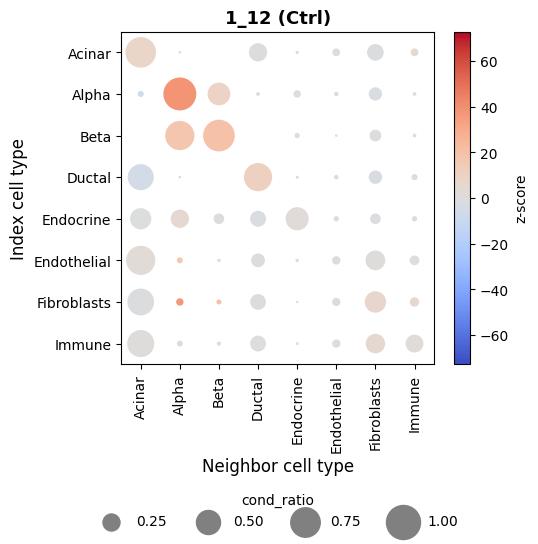

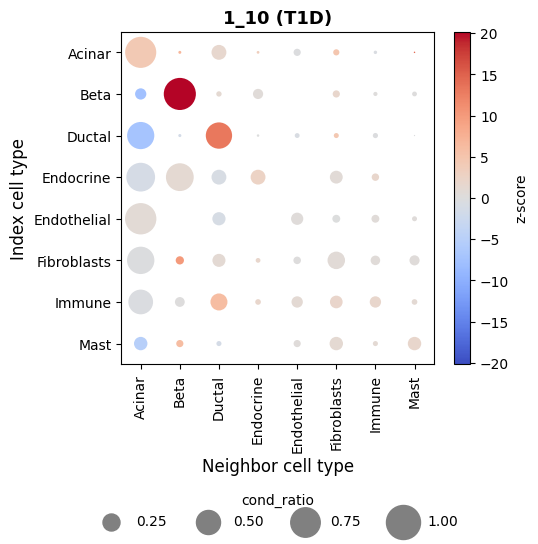

In [8]:
# one dot plot per slide
for condition, slide in SLIDES.items():
    fig, ax = cozi_dotplot(res_all[slide],
                           title=f"{slide} ({condition})",
                           code_to_ct=code_to_ct)
    fig.tight_layout()
    stem = f"cozi_dotplot_{slide}_{CT_KEY}_{NBH_DEF}{RADIUS}"
    fig.savefig(OUT_DIR / f"{stem}.png", dpi=300, bbox_inches="tight")
    fig.savefig(OUT_DIR / f"{stem}.pdf", bbox_inches="tight")
    plt.show()

#### Side-by-side comparison

Same figure with a shared, symmetric color scale so the two conditions can be compared directly.


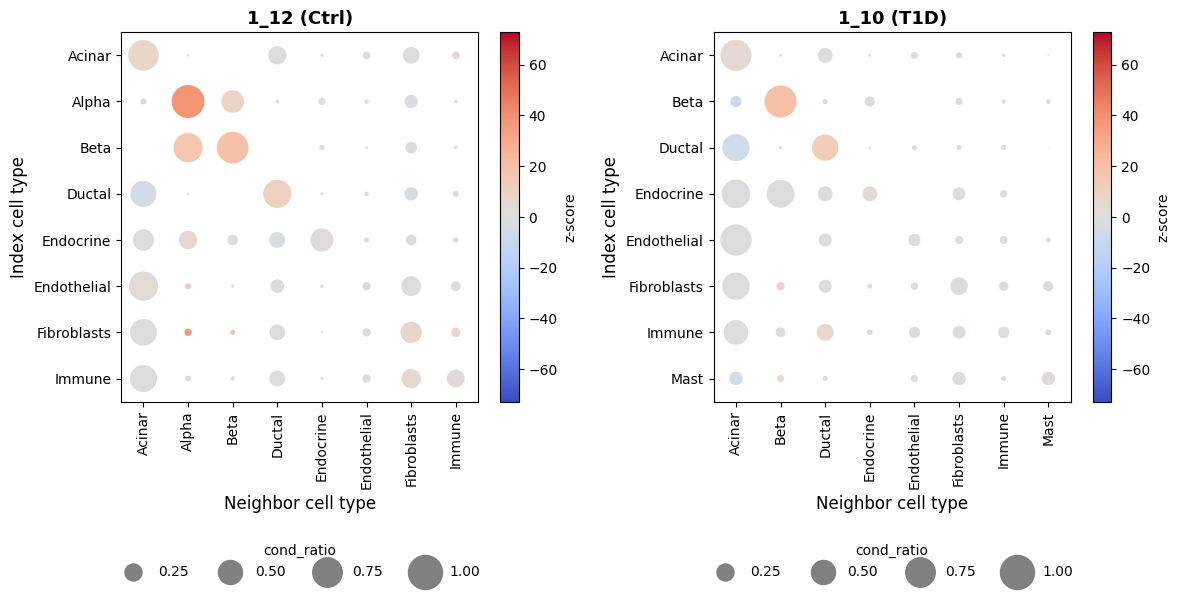

In [9]:
vmax = max(np.nanmax(np.abs(res["zscore"].values)) for res in res_all.values())

fig, axes = plt.subplots(1, len(SLIDES), figsize=(6 * len(SLIDES), 6.5))
for ax, (condition, slide) in zip(np.atleast_1d(axes), SLIDES.items()):
    cozi_dotplot(res_all[slide], ax=ax, title=f"{slide} ({condition})",
                 code_to_ct=code_to_ct, vmax=vmax)

fig.tight_layout()
stem = f"cozi_dotplot_{'_'.join(SLIDES.values())}_{CT_KEY}_{NBH_DEF}{RADIUS}"
fig.savefig(OUT_DIR / f"{stem}.png", dpi=300, bbox_inches="tight")
fig.savefig(OUT_DIR / f"{stem}.pdf", bbox_inches="tight")
plt.show()

> COZIpy z-scores should always be interpreted together with the conditional cell ratio, see
> [Schiller *et al.* 2026](https://doi.org/10.1038/s41467-026-71699-z).
